In [1]:
# --- Preload QWen and DAM models ---
import time
from hanoi_caption.image_describer import MODEL_NAME as QWEN_NAME
from hanoi_caption.region_describer import MODEL_NAME as DAM_NAME
from hanoi_caption.model_registry import registry
print("Preloading QWen and DAM models into memory...")
t0 = time.perf_counter()
# Load QWen
registry.get(QWEN_NAME)
print(f"QWen loaded. ({(time.perf_counter() - t0):.1f}s)")
# Load DAM
t1 = time.perf_counter()
registry.get(DAM_NAME)
print(f"DAM loaded. ({(time.perf_counter() - t1):.1f}s)")
print("\nModels successfully preloaded!")
print("Current loaded models:", registry.loaded())

Preloading QWen and DAM models into memory...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

QWen loaded. (13.9s)


Fetching 20 files:   0%|          | 0/20 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

DAM loaded. (5.0s)

Models successfully preloaded!
Current loaded models: ['qwen25_vl_3b', 'dam_3b']


In [2]:
import sys; sys.path.insert(0, "..")
from pathlib import Path
import json
import torch
from PIL import Image
import matplotlib.pyplot as plt

from hanoi_caption.kb_loader import load_kb
from hanoi_caption.kb_indexer import build_or_load_index
from hanoi_caption.pipeline import caption_phase1, caption_phase2
from hanoi_caption.model_registry import registry

nodes = load_kb("../data/kb.json")
kb_index = build_or_load_index(nodes)
print(f"KB ready: {len(nodes)} nodes")

KB ready: 72 nodes


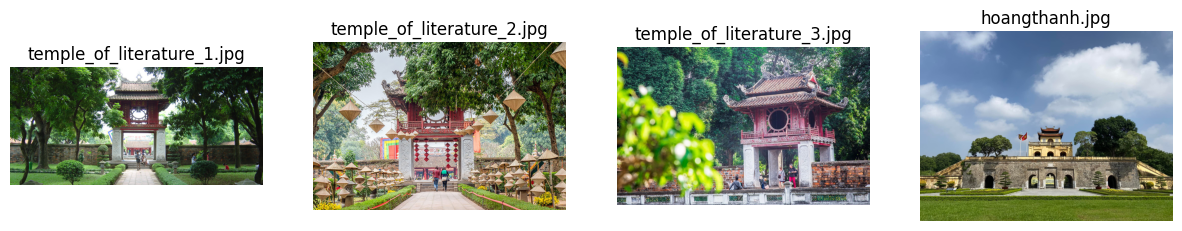

In [3]:
photos = [
    Path("../tests/fixtures/temple_of_literature_1.jpg"),
    Path("../tests/fixtures/temple_of_literature_2.jpg"),
    Path("../tests/fixtures/temple_of_literature_3.jpg"),
    Path("../tests/fixtures/hoangthanh.jpg"),
    Path("../tests/fixtures/gahanoi.jpg"),
    Path("../tests/fixtures/nhakhach.jpg"),
]
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for ax, p in zip(axes, photos):
    ax.imshow(Image.open(p)); ax.set_title(p.name); ax.axis("off")
plt.show()

In [ ]:
phase1_results = []
for p in photos:
    img = Image.open(p).convert("RGB")
    r = caption_phase1(image=img, kb_nodes=nodes, kb_index=kb_index)
    phase1_results.append(r)
    print(f"\n--- Phase 1: {p.name} ---")
    print(r.caption or r.refusal)

In [ ]:
import time

phase2_results = []
p = photos[0]
img = Image.open(p).convert("RGB")

t0 = time.perf_counter()
r = caption_phase2(image=img, kb_nodes=nodes, kb_index=kb_index)
elapsed = time.perf_counter() - t0

phase2_results.append(r)
print(f"\n--- Phase 2: {p.name}  (caption generated in {elapsed:.1f}s) ---")
print(r.caption or r.refusal)
print(f"  regions: {r.debug.get('n_regions')}, queries: {r.debug.get('queries')}")
timings = r.debug.get("timings", {})
if timings:
    print("\nPer-stage timings:")
    for name, secs in timings.items():
        print(f"  {name:18s}  {secs:6.2f}s")
    print(f"  {'sum':18s}  {sum(timings.values()):6.2f}s")


In [ ]:
import time
from hanoi_caption.pipeline_retriever import caption_retriever

retriever_results = []
timing_data = []  # List of dicts: {photo, stage1, stage2, ..., total}

print("=" * 80)
print("RETRIEVER PIPELINE: BATCH PROCESSING ALL PHOTOS")
print("=" * 80)

def _name(node_id):
    return nodes[node_id].name_en if node_id in nodes else "?"

for photo_idx, p in enumerate(photos, start=1):
    img = Image.open(p).convert("RGB")
    
    t0 = time.perf_counter()
    r = caption_retriever(image=img, kb_nodes=nodes, kb_index=kb_index)
    elapsed = time.perf_counter() - t0
    
    retriever_results.append(r)
    
    # Build timing dict for this photo
    photo_timings = {"photo": p.name, "total": elapsed}
    stage_timings = r.debug.get("timings", {})
    photo_timings.update(stage_timings)
    timing_data.append(photo_timings)
    
    # Print per-photo results (same format as original cell)
    print(f"\n--- Retriever-only [{photo_idx}/6]: {p.name}  (caption generated in {elapsed:.1f}s) ---")
    print(r.caption or r.refusal)
    
    match = r.debug.get("match", {})
    chosen_id = match.get("node_id")
    top_k = match.get("top_k") or []
    
    if chosen_id and chosen_id in nodes:
        print(f"\nMatched: {_name(chosen_id)!r}  (id {chosen_id}, confidence {match.get('confidence', 0):.3f})")
    elif top_k:
        print(f"\nNo match (rerank refused). Cosine top-1 was {_name(top_k[0]['node_id'])!r} @ {top_k[0]['score']:.3f}")
    
    if top_k:
        print("\nCosine top-5:")
        for c in top_k[:5]:
            marker = "  <-- rerank pick" if c["node_id"] == chosen_id else ""
            print(f"  {c['score']:.3f}  {_name(c['node_id'])!r}{marker}")
    
    if stage_timings:
        print("\nPer-stage timings:")
        for name, secs in stage_timings.items():
            print(f"  {name:18s}  {secs:6.2f}s")
        print(f"  {'total':18s}  {sum(stage_timings.values()):6.2f}s")

print("\n" + "=" * 80)
print(f"Completed batch processing of {len(retriever_results)} photos")
print("=" * 80)

In [ ]:
def jaccard(a: str, b: str) -> float:
    sa, sb = set(a.lower().split()), set(b.lower().split())
    return len(sa & sb) / len(sa | sb) if sa | sb else 0.0

print("Phase 1 pairwise word-jaccard:")
print(f"  1-2: {jaccard(phase1_results[0].caption, phase1_results[1].caption):.2f}")
print(f"  1-3: {jaccard(phase1_results[0].caption, phase1_results[2].caption):.2f}")
print(f"  2-3: {jaccard(phase1_results[1].caption, phase1_results[2].caption):.2f}")
print("\nPhase 2 pairwise word-jaccard:")
print(f"  1-2: {jaccard(phase2_results[0].caption, phase2_results[1].caption):.2f}")
print(f"  1-3: {jaccard(phase2_results[0].caption, phase2_results[2].caption):.2f}")
print(f"  2-3: {jaccard(phase2_results[1].caption, phase2_results[2].caption):.2f}")

In [ ]:
import base64, io, numpy as np
img = Image.open(photos[0]).convert("RGB")
result = caption_phase2(image=img, kb_nodes=nodes, kb_index=kb_index)
regions = result.debug["regions"]
print(f"queries fired: {result.debug['queries']}")
print(f"regions kept : {len(regions)}")
for r in regions[:6]:
    print(f"  {r['query']!r} score={r['score']:.2f}")

In [ ]:
print("loaded:", registry.loaded())
print(f"VRAM allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"VRAM peak: {torch.cuda.max_memory_allocated()/1e9:.2f} GB")